In [78]:
import json
import ssl

import torch
from torch import nn, optim
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import OxfordIIITPet

from src.dataset import define_transformations
from src.experiment import prepare_results_dir, save_results
from src.metrics import plot_training_metrics
from src.training import training_loop

ssl._create_default_https_context = ssl._create_unverified_context
from torchvision.models import MobileNet_V3_Large_Weights, mobilenet_v3_large

In [79]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [80]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

batch_size = int(config_json["data"]["batch_size"])
augmentation = config_json["data"]["augmentation"]

model = config_json["model"]["name"]
dropout = config_json["model"]["dropout"]

learning_rate = float(config_json["training"]["learning_rate"])
weight_decay = float(config_json["training"]["weight_decay"])
scheduler_config = config_json["training"]["scheduler"]
epochs = int(config_json["training"]["epochs"])

early_stopping_config = config_json["training"]["early_stopping"]
early_stopping_patience = int(early_stopping_config["patience"])
early_stopping_min_delta = float(early_stopping_config["min_delta"])

In [81]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transform, val_transform = define_transformations(augmentation, IMAGENET_MEAN, IMAGENET_STD)
train_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)
test_dataset = OxfordIIITPet(
    root="../data",
    split="test",
    target_types="category",
    download=True,
    transform=val_transform
)

In [82]:
train_split = random_split(train_dataset,
                     [0.7, 0.3],
                     generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_split[0], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(train_split[1], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [83]:
num_classes = len(train_dataset.classes)
print(f"{num_classes} classes found.")

37 classes found.


In [84]:
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
model = mobilenet_v3_large(weights=weights)

In [85]:
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

In [86]:
for param in model.parameters():
    param.requires_grad = False

In [87]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)


In [88]:
model.classifier[3]

Linear(in_features=1280, out_features=1000, bias=True)

In [89]:
model.classifier[3] = nn.Linear(
    in_features=model.classifier[3].in_features,
    out_features=num_classes,
)

In [90]:
model = model.to(device)

In [91]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_decay,
)
loss_function = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=scheduler_config["mode"],
    factor=float(scheduler_config["factor"]),
    patience=int(scheduler_config["patience"]),
    min_lr=float(scheduler_config["min_lr"]),
)

In [92]:
results_dir, exp_number, exp_path = prepare_results_dir()
print("Results Directory:", results_dir)
print("Experiment Number:", exp_number)
print("Experiment Path:", exp_path)

Results Directory: experiments
Experiment Number: 4
Experiment Path: experiments/4


In [93]:
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=epochs,
    device=device,
    scheduler=scheduler,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
)

--- Training Started ---
Epoch [1/50], Train Loss: 3.2460, Train Accuracy: 30.36% Val Loss: 2.7569, Val Accuracy: 60.42%
Epoch [2/50], Train Loss: 2.5333, Train Accuracy: 59.90% Val Loss: 2.1327, Val Accuracy: 69.93%
Epoch [3/50], Train Loss: 2.0495, Train Accuracy: 67.08% Val Loss: 1.7391, Val Accuracy: 71.11%
Epoch [4/50], Train Loss: 1.7190, Train Accuracy: 69.64% Val Loss: 1.4956, Val Accuracy: 73.19%
Epoch [5/50], Train Loss: 1.4888, Train Accuracy: 73.25% Val Loss: 1.3718, Val Accuracy: 73.91%
Epoch [6/50], Train Loss: 1.3508, Train Accuracy: 72.79% Val Loss: 1.2415, Val Accuracy: 73.73%
Epoch [7/50], Train Loss: 1.2589, Train Accuracy: 74.18% Val Loss: 1.2173, Val Accuracy: 73.73%
Epoch [8/50], Train Loss: 1.1683, Train Accuracy: 75.58% Val Loss: 1.1389, Val Accuracy: 72.74%
Epoch [9/50], Train Loss: 1.0828, Train Accuracy: 77.29% Val Loss: 1.1233, Val Accuracy: 73.10%
Epoch [10/50], Train Loss: 1.0348, Train Accuracy: 76.67% Val Loss: 1.0715, Val Accuracy: 74.09%
Epoch [11/50],


--- Training Plots ---



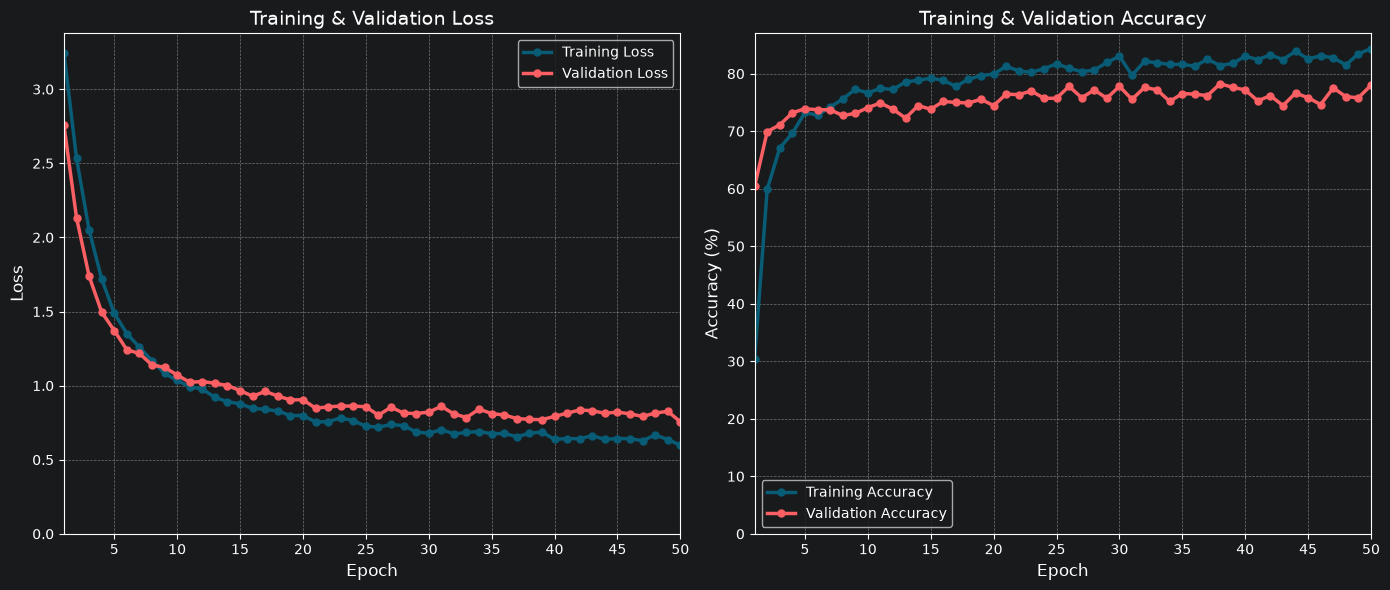

In [94]:
print("\n--- Training Plots ---\n")
plot_training_metrics(training_metrics, exp_path)

In [95]:
save_results(results_dir,
             exp_path,
             exp_number,
             learning_rate,
             training_metrics,
             model.__class__.__name__,
             len(training_metrics[0]),
             batch_size,
             optimizer.__class__.__name__,
             weight_decay,
             seed,
             str(augmentation),
             dropout,
             scheduler_config
             )